In [1]:
import sys

# ── path setup ──────────────────────────────────────────────────────────────
# Each entry below adds a specific directory so its modules can be imported
# directly (bare name), WITHOUT triggering that directory's __init__.py and
# its full dependency chain. This avoids the two-different-"functions"-
# packages name collision entirely — never `import functions` itself.
sys.path.insert(0, "/home/hcr64/Pinyon-Detection")                                  # global_files/
sys.path.insert(0, "/home/hcr64/Pinyon-Detection/modelling/functions")              # feature_config.py, standalone
sys.path.insert(0, "/home/hcr64/Pinyon-Detection/modelling/functions/features")     # diagnose_cluster_bimodality.py — adjust if saved elsewhere
sys.path.insert(0, "/home/hcr64/Pinyon-Detection/clustering/functions/detection")   # split_large_clusters.py — adjust if saved elsewhere

# ── third-party ────────────────────────────────────────────────────────────
from pyntcloud import PyntCloud
from plyfile import PlyData
import numpy as np
import os
import pandas as pd
import random
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# ── project: paths + cached dataframes/clusters ───────────────────────────
from global_files import load_clusters, load_dataframes, get_paths, save_clusters

# ── project: feature list (standalone, no torch/xgboost/lightgbm pulled in) ─
from feature_config import FEATURES

# ── project: bimodality diagnostics ────────────────────────────────────────
from diagnose_cluster_bimodality import (
    diagnose_all_clusters,
    diagnose_cluster_bimodality,
    calibrate_thresholds,
    explain_why_not_flagged,
    get_color_spatial_override_candidates,
    get_flagged_cluster_paths,
    get_flagged_indices_from_sources,
)

# ── project: colour-augmented splitting ────────────────────────────────────
sys.path.insert(0, "/home/hcr64/Pinyon-Detection/clustering/functions/detection")  # wherever you actually saved this file
from split_large_clusters import split_large_clusters, find_density_peaks, filter_cluster

# ── paths + data ────────────────────────────────────────────────────────────

# paths and other constants
TRIAL_NAME      = 'Sunset_sfm_trial'
PATHS = get_paths( TRIAL_NAME )

DATAFRAMES_PATH = PATHS['Dataframes']
CLUSTERS_PATH   = PATHS['Clusters']

df_clusters, df_deep_clusters = load_dataframes( DATAFRAMES_PATH )
clusters = load_clusters( CLUSTERS_PATH )

df_pred = pd.read_csv(DATAFRAMES_PATH + "predictions.csv")
df_pred.head()

# confirm
print( PATHS['Clusters'] )

print(len(clusters), len(df_clusters))  # sanity check — should match; if not, see the sync-mismatch note from earlier

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Loaded df_clusters      (2000 rows) ← /home/hcr64/Pinyon-Detection/clustering/trial_data/Sunset_sfm_trial/dataframes/clusters.csv
Loaded df_deep_clusters (2000 rows) ← /home/hcr64/Pinyon-Detection/clustering/trial_data/Sunset_sfm_trial/dataframes/deep_clusters.csv
2000 2000


In [2]:
# function to draw a window with a pointcloud in it
def visualize_pointcloud(pcd_path, point_size=2, background_color="black"):

    plydata = PlyData.read(pcd_path)
    vertex = plydata['vertex']

    points = np.vstack([vertex['x'], vertex['y'], vertex['z']]).T

    # use color if available, otherwise default to white
    vertex_names = vertex.data.dtype.names
    if 'red' in vertex_names and 'green' in vertex_names and 'blue' in vertex_names:
        r = vertex['red']
        g = vertex['green']
        b = vertex['blue']
        color_str = [f"rgb({int(r_)},{int(g_)},{int(b_)})" for r_, g_, b_ in zip(r, g, b)]
    else:
        color_str = "white"

    fig = go.Figure(data=[go.Scatter3d(
        x=points[:, 0],
        y=points[:, 1],
        z=points[:, 2],
        mode="markers",
        marker=dict(
            size=point_size,
            color=color_str,
        )
    )])

    fig.update_layout(
        scene=dict(bgcolor=background_color),
        paper_bgcolor="black",
    )

    fig.show()

In [3]:
# paths and other constants
TRIAL_NAME      = 'Sunset_sfm_trial'
PATHS = get_paths( TRIAL_NAME )

DATAFRAMES_PATH = PATHS['Dataframes']
CLUSTERS_PATH   = PATHS['Clusters']

df_pred = pd.read_csv(DATAFRAMES_PATH + "predictions.csv")
df_pred.head()

# confirm
print( PATHS['Clusters'] )


/scratch/hcr64/Pinyon-Detection/data/Sunset_sfm_trial/clusters/


In [4]:
# get the cluster ids of mismatched clusters
df_mismatch = pd.read_csv(PATHS['Dataframes'] + 'pinyon_misclassification_report.csv')

id_col = "file" if "file" in df_mismatch.columns else df_mismatch.columns[0]
mismatched_ids = df_mismatch[id_col].astype(int).tolist()

print(f"{len(mismatched_ids)} mismatched clusters")
print(mismatched_ids)
cluster = 0

6 mismatched clusters
[1385, 1361, 1469, 539, 716, 993]


In [5]:
# get confident pinyons
df_pred = pd.read_csv(DATAFRAMES_PATH + "predictions.csv")

#df_confident = df_pred[df_pred["high_confidence"]]        # only >80% confident
df_pinyon_confident = df_pred[(df_pred["predicted_label"] == "pinyon") & (df_pred["prob_pinyon"] > 0.9)]

# look at it
len( df_pinyon_confident )
df_pinyon_confident.head()

,file,predicted_label,prob_juniper,prob_pinyon,prob_ponderosa,x_pos,y_pos,height,radius,n_points,Name,label_distance
7,7,pinyon,0.034653,0.930603,0.034744,461651.557,3917619.614,3.709,2.336,607,unknown,inf
12,12,pinyon,0.008070,0.987599,0.004331,461867.208,3917615.319,3.572,3.628,636,unknown,inf
19,19,pinyon,0.030935,0.940229,0.028837,461712.235,3917614.054,5.159,3.215,1485,unknown,inf
25,25,pinyon,0.069903,0.900395,0.029702,461595.762,3917611.403,2.736,2.160,109,unknown,inf
29,29,pinyon,0.041201,0.935649,0.023149,461825.397,3917612.918,1.938,1.595,82,unknown,inf


1613
/scratch/hcr64/Pinyon-Detection/data/Sunset_sfm_trial/clusters/cluster1613.ply


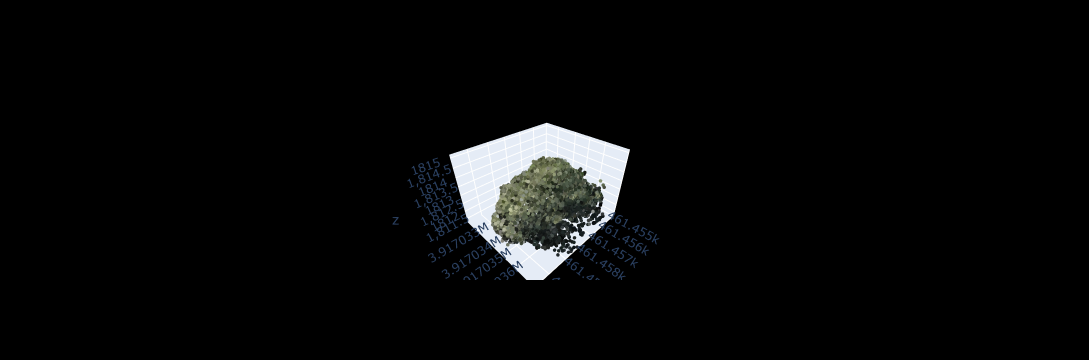

In [17]:
# get the path of desired pointcloud
cluster_id = int(df_pinyon_confident["file"].sample(1).iloc[0])

#cluster_id = df_pinyon_confident.()['file']
print( cluster_id )
PLY_PATH = PATHS['Clusters'] +  f"cluster{cluster_id}.ply"   # change per cluster
# cluster += 1

# call the function on it
print( PLY_PATH )
visualize_pointcloud( PLY_PATH )

In [7]:
PATHS = get_paths("Sunset_sfm_trial")
clusters = load_clusters(PATHS['Clusters'])
labeled_clusters = load_clusters(PATHS['Labeled_clusters'])

df_diag = diagnose_all_clusters(
    clusters,
    save_path=PATHS['Images'] + 'bimodality_diagnostics/',
)

flagged = df_diag.loc[df_diag["color_bimodal_spatial_unimodal"], "file"].unique()
print(sorted(flagged))

Running bimodality diagnostic on all 2000 clusters — this checks every cluster in the trial, expect more candidates than a targeted run and treat flags as leads for visual inspection, not confirmed merges.

  ⚠  cluster 2 flagged (n_points=286, n_spatial_peaks=1, strongest feature=chroma_b)
  ⚠  cluster 16 flagged (n_points=225, n_spatial_peaks=1, strongest feature=chroma_b)
  ⚠  cluster 18 flagged (n_points=359, n_spatial_peaks=1, strongest feature=chroma_g)
  ⚠  cluster 21 flagged (n_points=283, n_spatial_peaks=1, strongest feature=chroma_b)
  ⚠  cluster 34 flagged (n_points=99, n_spatial_peaks=1, strongest feature=chroma_r)
  ⚠  cluster 38 flagged (n_points=244, n_spatial_peaks=1, strongest feature=chroma_g)
  ⚠  cluster 45 flagged (n_points=121, n_spatial_peaks=1, strongest feature=chroma_r)
  ⚠  cluster 52 flagged (n_points=256, n_spatial_peaks=1, strongest feature=chroma_g)
  ⚠  cluster 57 flagged (n_points=65, n_spatial_peaks=1, strongest feature=chroma_g)
  ⚠  cluster 58 flagge

KeyboardInterrupt: 

In [ ]:
from diagnose_cluster_bimodality import calibrate_thresholds
df_clusters, df_deep_clusters = load_dataframes(PATHS['Dataframes']) 

comparison_indices = [1399, 1375, 1483, 545, 1006, 1744] + list(df_clusters.sample(15, random_state=1)["file"])
df_cal = calibrate_thresholds(clusters, comparison_indices)

In [ ]:
from diagnose_cluster_bimodality import explain_why_not_flagged

explain_why_not_flagged(
    clusters,
    [1399, 1375, 1483, 545, 1006, 1744],
    max_radius=4.25,   # from pinyons.sh, so you can see the production-gate context too
)

In [ ]:
from diagnose_cluster_bimodality import get_color_spatial_override_candidates
#from split_large_clusters import split_large_clusters

override_indices = get_color_spatial_override_candidates(
    clusters, [1399, 1375, 1483, 545, 1006, 1744]
)
# expect [1399, 1375, 1483] back, given what you already saw

test_split = split_large_clusters(
    [clusters[i] for i in override_indices],  # just these 3, for a fast isolated test
    min_points=40, max_radius=4.25, min_peak_distance=3.0,
    use_color=True, color_weight=10.0,
    force_check_indices=set(range(len(override_indices))),  # indices within this small sublist
    save_pre_split_path="/scratch/hcr64/test_override_split/",
)

In [ ]:
from diagnose_cluster_bimodality import get_flagged_cluster_paths

df_diag = diagnose_all_clusters(
    clusters,
    delta_bic_threshold=10.0,
    separation_threshold=1.0,
    spatial_separation_ratio=0.75,
    min_intercentroid_m=0.3,
    min_spatial_group_size=15,
    save_path=PATHS['Images'] + 'bimodality_diagnostics/',
)
flagged_paths = get_flagged_cluster_paths(df_diag, PATHS['Clusters'])
print(flagged_paths)

In [ ]:
  flagged = df_diag.loc[df_diag["color_bimodal_spatial_unimodal"], "file"].unique()
  print(sorted(flagged))

In [ ]:
flagged_indices = sorted(df_diag.loc[df_diag["color_bimodal_spatial_unimodal"], "file"].unique().tolist())
print(len(flagged_indices))

confirmed = {1399, 1375, 1483}   # passed color+spatial gates in your earlier explain_why_not_flagged run
rejected  = {545, 1006, 1744}    # failed the spatial gate or found no bimodality

print("known confirmed present:", confirmed & set(flagged_indices))   # should be all 3
print("known rejected present:", rejected & set(flagged_indices))     # should be none

In [ ]:
cluster=0

In [ ]:
flagged_indices
cluster_id = flagged_indices[cluster]
PLY_PATH = PATHS['Clusters'] +  f"cluster{cluster_id}.ply"   # change per cluster
cluster += 1

# call the function on it
print( PLY_PATH )
visualize_pointcloud( PLY_PATH )

In [ ]:
MAX_RADIUS = 4.25  # from pinyons.sh

below_gate, above_gate = [], []
for idx in flagged_indices:
    pcd = clusters[idx]
    aabb = pcd.get_axis_aligned_bounding_box()
    radius = max((aabb.max_bound - aabb.min_bound)[:2]) / 2
    (below_gate if radius <= MAX_RADIUS else above_gate).append(idx)

print(f"{len(below_gate)} flagged clusters sit at/below max_radius — "
      f"production split_large_clusters() skips these entirely (gate 1)")
print(f"{len(above_gate)} flagged clusters sit above max_radius — "
      f"production would already attempt a split on these; worth checking "
      f"why it isn't succeeding (Mean Shift not converging to 2 modes, or "
      f"filter_cluster rejecting the sub-clusters)")

In [ ]:
from diagnose_cluster_bimodality import get_flagged_cluster_paths
import random

paths = get_flagged_cluster_paths(df_diag, PATHS['Clusters'])
sample = random.sample(paths, min(15, len(paths)))
print(sample)